# FER2013 Emotion Recognition — v2
### Fixes in this version
1. **Augmentation applied BEFORE normalization** (was corrupting MobileNetV2 inputs)
2. **MobileNetV2 preprocessing via `tf.keras.applications.mobilenet_v2.preprocess_input`** (correct [-1,1] scaling)
3. **Stage 1 uses higher LR (1e-3)** so the head actually converges
4. **Augmentation only on pixel [0,255] range**, then normalize
5. **CNN stays the same** (already 66% ✓)


In [50]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


## Configuration

In [51]:
DATASET_PATH    = '/kaggle/input/datasets/deadskull7/fer2013/fer2013.csv'
IMG_SIZE        = 48
IMG_SIZE_TL     = 96
BATCH_SIZE      = 64
EPOCHS          = 50
EPOCHS_FINETUNE = 20

## Load & Prepare Dataset

In [52]:
df = pd.read_csv(DATASET_PATH)

# Merge Disgust(1) -> Angry(0), shift remaining labels down
df['emotion'] = df['emotion'].replace(1, 0)
df.loc[df['emotion'] > 1, 'emotion'] -= 1

NUM_CLASSES    = 6
EMOTION_LABELS = ['Angry', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

train_df = df[df['Usage'] == 'Training']
val_df   = df[df['Usage'] == 'PublicTest']
print('Train:', len(train_df), '| Val:', len(val_df))
print(df['emotion'].value_counts().sort_index())

Train: 28709 | Val: 3589
emotion
0    5500
1    5121
2    8989
3    6077
4    4002
5    6198
Name: count, dtype: int64


## Class Weights

In [53]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['emotion'].values
)
class_weight_dict = dict(enumerate(weights))
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(1.0798540585270444), 1: np.float64(1.1678870718411847), 2: np.float64(0.6631785631785632), 3: np.float64(0.9906487232574189), 4: np.float64(1.5089351413854726), 5: np.float64(0.9637126552534407)}


## Shared Callbacks Factory

In [54]:
def make_callbacks(ckpt_path, patience_es=10, patience_lr=5, min_lr=1e-6):
    return [
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_lr,
                          min_lr=min_lr, verbose=1),
        EarlyStopping(monitor='val_loss', patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

---
# Part 1 — CNN Baseline (unchanged, ~66% val acc)

In [55]:
def preprocess_cnn(pixel_string, label):
    pixels = tf.strings.split(pixel_string)
    pixels = tf.strings.to_number(pixels, tf.float32)
    image  = tf.reshape(pixels, [48, 48, 1]) / 255.0
    label  = tf.one_hot(label, NUM_CLASSES)
    return image, label

train_ds = (tf.data.Dataset
    .from_tensor_slices((train_df['pixels'].values, train_df['emotion'].values))
    .map(preprocess_cnn, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset
    .from_tensor_slices((val_df['pixels'].values, val_df['emotion'].values))
    .map(preprocess_cnn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

In [56]:
aug = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='aug_cnn')

l2 = regularizers.L2(1e-4)
inp = tf.keras.Input(shape=(48, 48, 1))
x = aug(inp)

for filters in [32, 64, 128, 256]:
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=l2)(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=l2)(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

cnn_model = Model(inp, out, name='cnn_baseline')
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_cnn (Sequential)            │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,02

 Total params: 1,274,982 (4.86 MB)

 Trainable params: 1,273,062 (4.86 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [57]:
history_cnn = cnn_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, class_weight=class_weight_dict,
    callbacks=make_callbacks('best_cnn.keras')
)

Epoch 1/50


E0000 00:00:1772963876.357170      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_baseline_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1772963879.551392     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.1878 - loss: 2.0442 - val_accuracy: 0.2229 - val_loss: 1.8844 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.2403 - loss: 1.8359 - val_accuracy: 0.3739 - val_loss: 1.6878 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.3570 - loss: 1.6777 - val_accuracy: 0.4469 - val_loss: 1.5211 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4246 - loss: 1.5784 - val_accuracy: 0.4904 - val_loss: 1.4301 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4657 - loss: 1.5149 - val_accuracy: 0.5060 - val_loss: 1.3992 - learning_rate: 0.0010
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4871 - loss: 1.4653 - val_accuracy: 0.5249 - val_loss: 1.3525 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.5025 - loss: 1.4457

---
# Part 2 — Transfer Learning (MobileNetV2) — FIXED

**Key fix:** augmentation runs on raw `[0, 255]` uint8-range pixels,  
then `mobilenet_preprocess` converts to `[-1, 1]` as the backbone expects.

## Preprocessing (correct order: augment → preprocess_input)

In [58]:
# ── Augmentation operates on [0, 1] float images (before MobileNet scaling) ──
#    RandomFlip / Rotation / Zoom are scale-invariant so [0,1] is fine.
#    We do NOT include contrast here because it interacts badly with
#    the subsequent [-1,1] shift.

aug_tl = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='aug_tl')


def preprocess_tl(pixel_string, label):
    """
    1. Parse pixels → [0, 1] float
    2. Resize to (IMG_SIZE_TL, IMG_SIZE_TL) & convert to RGB
    3. Scale to [0, 255] so mobilenet_preprocess can do its job
       (preprocess_input expects values in [0, 255] and returns [-1, 1])
    """
    pixels = tf.strings.split(pixel_string)
    pixels = tf.strings.to_number(pixels, tf.float32)
    image  = tf.reshape(pixels, [48, 48, 1]) / 255.0           # [0,1]
    image  = tf.image.resize(image, (IMG_SIZE_TL, IMG_SIZE_TL))
    image  = tf.image.grayscale_to_rgb(image)                   # [0,1] RGB
    # DO NOT scale to [-1,1] here — that happens inside the model after augmentation
    label  = tf.one_hot(label, NUM_CLASSES)
    return image, label


train_ds_tl = (tf.data.Dataset
    .from_tensor_slices((train_df['pixels'].values, train_df['emotion'].values))
    .map(preprocess_tl, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds_tl = (tf.data.Dataset
    .from_tensor_slices((val_df['pixels'].values, val_df['emotion'].values))
    .map(preprocess_tl, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

## Build Model

In [59]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

tl_inp = tf.keras.Input(shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))

# Step 1: augment while still in [0, 1]
x = aug_tl(tl_inp)

# Step 2: scale [0,1] → [0,255] → mobilenet_preprocess → [-1,1]
x = layers.Rescaling(255.0)(x)                      # [0,1] → [0,255]
x = layers.Lambda(
    lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t),
    name='mobilenet_preprocess'
)(x)                                                 # [0,255] → [-1,1]

# Step 3: frozen base
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

# Step 4: classification head
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.L2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.L2(1e-4))(x)
x = layers.Dropout(0.4)(x)
tl_out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_tl = Model(tl_inp, tl_out, name='mobilenetv2_fer')
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),   # higher LR for head-only stage
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_fer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_tl (Sequential)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,590 (9.99 MB)

 Trainable params: 361,606 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Stage 1 — Train Head Only

In [60]:
history_tl_s1 = model_tl.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=make_callbacks('best_tl_s1.keras', patience_es=10, patience_lr=5)
)

print('\nBest Stage-1 val_accuracy:',
      max(history_tl_s1.history['val_accuracy']))

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.2488 - loss: 1.8751 - val_accuracy: 0.3709 - val_loss: 1.6069 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3255 - loss: 1.6653 - val_accuracy: 0.4046 - val_loss: 1.5560 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3527 - loss: 1.6103 - val_accuracy: 0.4333 - val_loss: 1.5161 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.3716 - loss: 1.5825 - val_accuracy: 0.4310 - val_loss: 1.5001 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.3814 - loss: 1.5595 - val_accuracy: 0.4227 - val_loss: 1.5120 - learning_rate: 0.0010
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3916 - loss: 1.5485 - val_accuracy: 0.4363 - val_loss: 1.5020 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3928 - l

## Stage 2 — Fine-tune Top 40 Layers

In [61]:
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Very small LR for fine-tuning
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Fine-tuning layers {fine_tune_at}–{len(base_model.layers)}')

history_tl_s2 = model_tl.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight_dict,
    callbacks=make_callbacks('best_tl_s2.keras', patience_es=8, patience_lr=4, min_lr=1e-7)
)

print('\nBest Stage-2 val_accuracy:',
      max(history_tl_s2.history['val_accuracy']))

Fine-tuning layers 114–154
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.2875 - loss: 1.7508 - val_accuracy: 0.4597 - val_loss: 1.4004 - learning_rate: 1.0000e-05
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.3562 - loss: 1.5826 - val_accuracy: 0.4673 - val_loss: 1.3892 - learning_rate: 1.0000e-05
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.3966 - loss: 1.5259 - val_accuracy: 0.4720 - val_loss: 1.3794 - learning_rate: 1.0000e-05
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.4145 - loss: 1.4855 - val_accuracy: 0.4776 - val_loss: 1.3721 - learning_rate: 1.0000e-05
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.4314 - loss: 1.4532 - val_accuracy: 0.4770 - val_loss: 1.3718 - learning_rate: 1.0000e-05
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.4413 - loss: 1.4410 - val_accuracy: 0.4868 - val_loss: 1.3729 - learning_rate: 1.0000e-05
Epoch 7/20
449/449 ━━━━━━

## Training History Plots

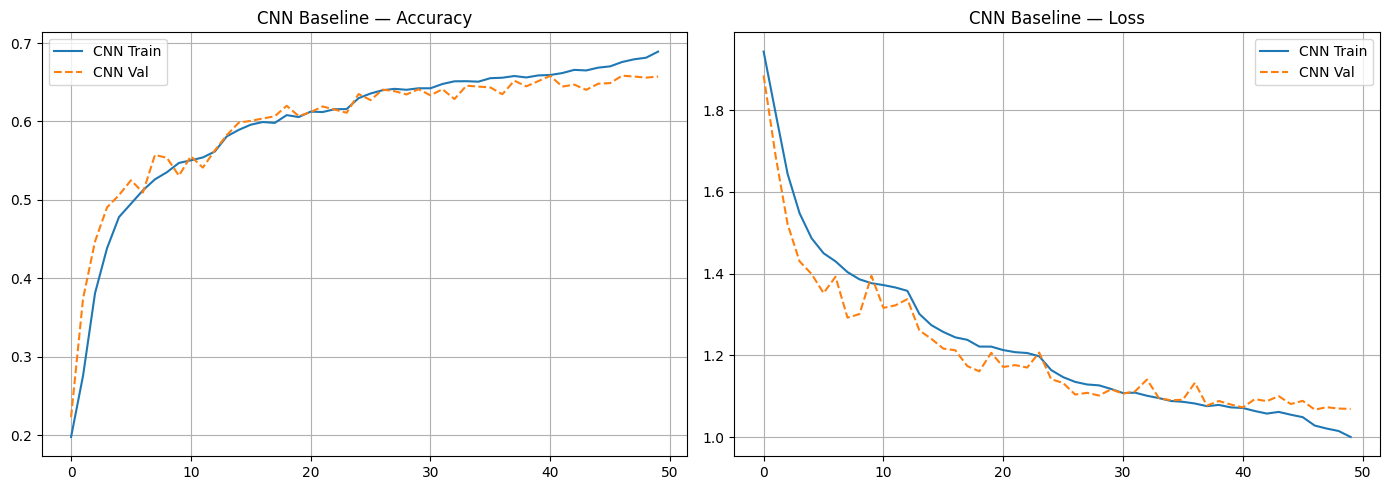

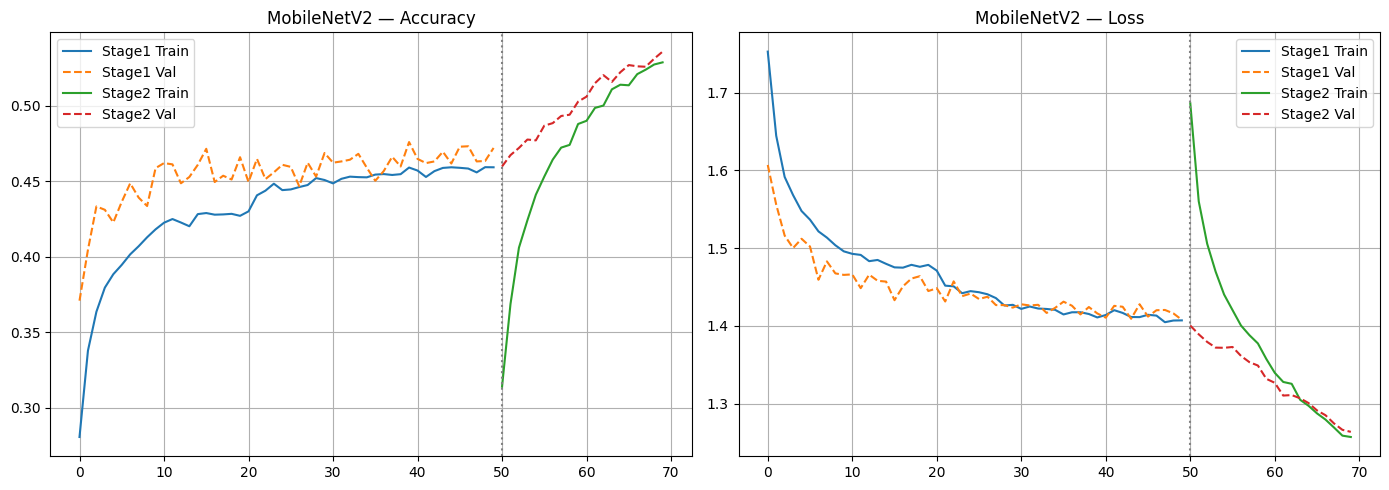

In [62]:
import matplotlib.pyplot as plt

def plot_history(histories, labels, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    offset = 0
    for h, lbl in zip(histories, labels):
        ep = range(offset, offset + len(h.history['accuracy']))
        ax1.plot(ep, h.history['accuracy'],     label=f'{lbl} Train')
        ax1.plot(ep, h.history['val_accuracy'], label=f'{lbl} Val', linestyle='--')
        ax2.plot(ep, h.history['loss'],         label=f'{lbl} Train')
        ax2.plot(ep, h.history['val_loss'],     label=f'{lbl} Val', linestyle='--')
        if offset > 0:
            ax1.axvline(x=offset, color='gray', linestyle=':')
            ax2.axvline(x=offset, color='gray', linestyle=':')
        offset += len(h.history['accuracy'])
    ax1.set_title(f'{title} — Accuracy'); ax1.legend(); ax1.grid(True)
    ax2.set_title(f'{title} — Loss');     ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_history.png', dpi=150)
    plt.show()

plot_history([history_cnn], ['CNN'], 'CNN Baseline')
plot_history([history_tl_s1, history_tl_s2], ['Stage1', 'Stage2'], 'MobileNetV2')

## Final Evaluation

In [63]:
print('=== CNN Baseline ===')
cnn_loss, cnn_acc = cnn_model.evaluate(val_ds, verbose=0)
print(f'Val Accuracy: {cnn_acc:.4f}  |  Val Loss: {cnn_loss:.4f}')

print('\n=== MobileNetV2 (after fine-tuning) ===')
tl_loss, tl_acc = model_tl.evaluate(val_ds_tl, verbose=0)
print(f'Val Accuracy: {tl_acc:.4f}  |  Val Loss: {tl_loss:.4f}')

=== CNN Baseline ===
Val Accuracy: 0.6584  |  Val Loss: 1.0676

=== MobileNetV2 (after fine-tuning) ===
Val Accuracy: 0.5358  |  Val Loss: 1.2637


## Save Models

In [ ]:
cnn_model.save('fer_cnn_model.keras')
model_tl.save('fer_transfer_learning_model.keras')
print('Both models saved.')

Both models saved.
